# Heart Disease Classification - HW3 Q2
## Author: ANR



In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

%matplotlib inline

np.random.seed(42)
torch.manual_seed(42)

## Load and explore data

In [25]:
df = pd.read_csv('heart.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [27]:
# check for issues
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Missing values: 0
Duplicates: 723


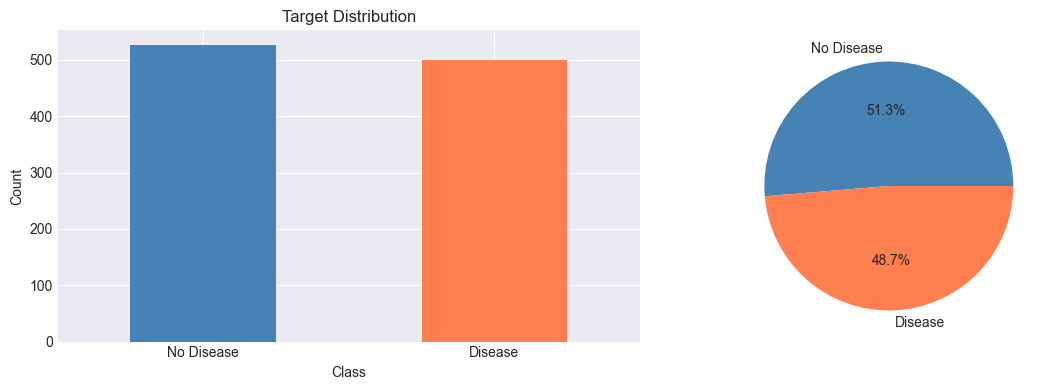

In [52]:
# visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Disease', 'Disease'], rotation=0)

df['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                  labels=['No Disease', 'Disease'], colors=['steelblue', 'coral'])
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

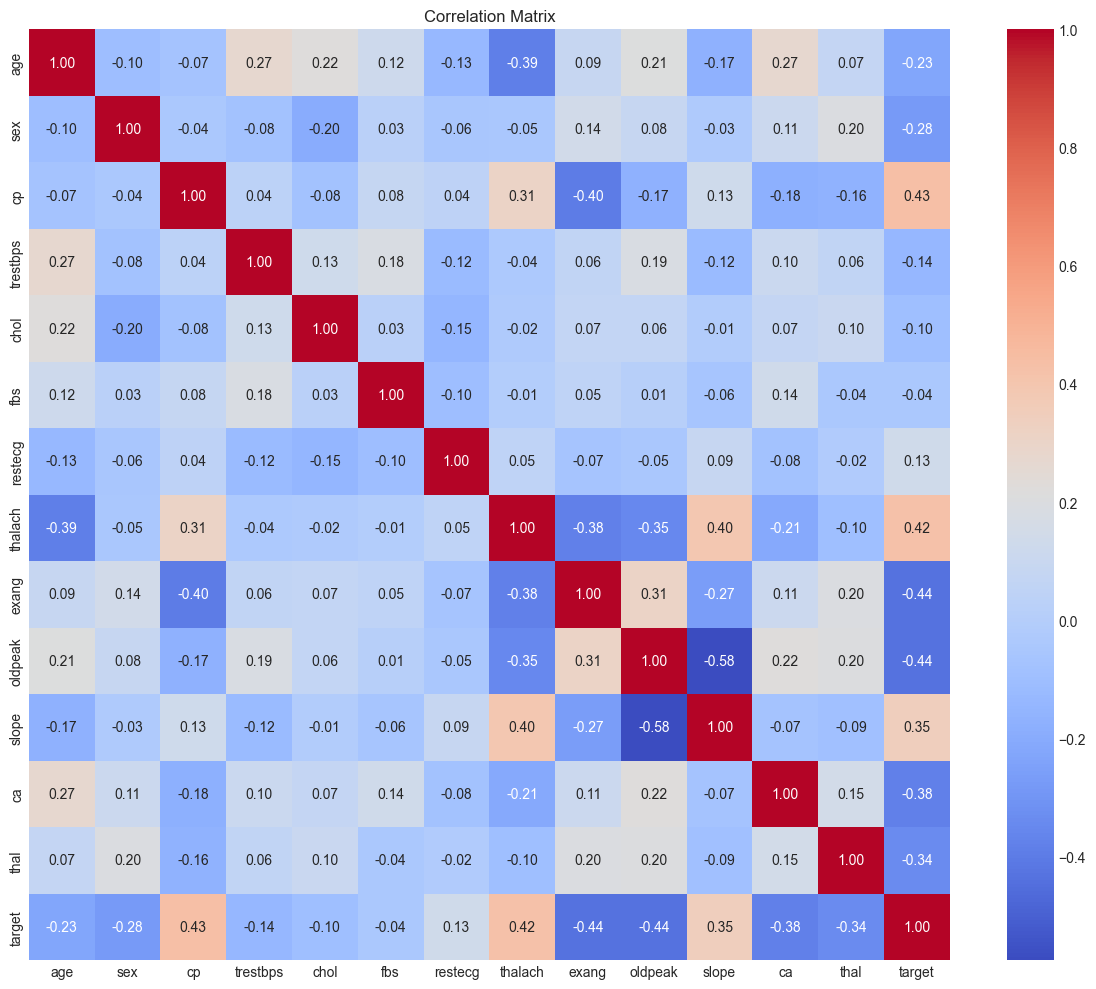

In [29]:
# correlation
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Prepare data

In [30]:
X = df.drop('target', axis=1).values
y = df['target'].values

print(f"Features: {X.shape}")
print(f"Labels: {y.shape}")

Features: (1025, 13)
Labels: (1025,)


In [31]:
# split data - 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)}")
print(f"Val: {len(X_val)}")
print(f"Test: {len(X_test)}")

Train: 717
Val: 154
Test: 154


In [32]:
# standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Test ML methods for comparsion

In [33]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
print(f"KNN: acc={knn_acc:.4f}, f1={knn_f1:.4f}")

KNN: acc=0.8636, f1=0.8679


In [34]:
# SVM with RBF kernel
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)
print(f"SVM: acc={svm_acc:.4f}, f1={svm_f1:.4f}")

SVM: acc=0.9481, f1=0.9487


In [35]:
# XGBoost
xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
print(f"XGBoost: acc={xgb_acc:.4f}, f1={xgb_f1:.4f}")

XGBoost: acc=0.9481, f1=0.9500


In [36]:
# CatBoost
cat = CatBoostClassifier(iterations=100, depth=4, learning_rate=0.1, random_state=42, verbose=False)
cat.fit(X_train, y_train)
cat_pred = cat.predict(X_test)
cat_acc = accuracy_score(y_test, cat_pred)
cat_f1 = f1_score(y_test, cat_pred)
print(f"CatBoost: acc={cat_acc:.4f}, f1={cat_f1:.4f}")

CatBoost: acc=0.9286, f1=0.9308


In [53]:
# store results for later comparison
results = {
    'KNN': {'acc': knn_acc, 'f1': knn_f1},
    'SVM': {'acc': svm_acc, 'f1': svm_f1},
    'XGBoost': {'acc': xgb_acc, 'f1': xgb_f1},
    'CatBoost': {'acc': cat_acc, 'f1': cat_f1}
}

## Build MLP model

Going to try a deeper network with good regularization

In [38]:
class HeartDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [39]:
# create datasets
train_ds = HeartDataset(X_train, y_train)
val_ds = HeartDataset(X_val, y_val)
test_ds = HeartDataset(X_test, y_test)

# data loaders - using small batch for better generalization
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

In [40]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        
        # tried [128, 64, 32] first but going deeper worked better
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.bn1 = nn.BatchNorm1d(hidden_dims[0])
        self.drop1 = nn.Dropout(0.45)  # higher dropout helps with small dataset
        
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.bn2 = nn.BatchNorm1d(hidden_dims[1])
        self.drop2 = nn.Dropout(0.45)
        
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.bn3 = nn.BatchNorm1d(hidden_dims[2])
        self.drop3 = nn.Dropout(0.35)
        
        self.fc4 = nn.Linear(hidden_dims[2], hidden_dims[3])
        self.bn4 = nn.BatchNorm1d(hidden_dims[3])
        self.drop4 = nn.Dropout(0.25)
        
        self.output = nn.Linear(hidden_dims[3], output_dim)
        
    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)
        
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.drop2(x)
        
        x = torch.relu(self.bn3(self.fc3(x)))
        x = self.drop3(x)
        
        x = torch.relu(self.bn4(self.fc4(x)))
        x = self.drop4(x)
        
        return self.output(x)

In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

# architecture: 256 -> 128 -> 64 -> 32
model = MLP(input_dim=13, hidden_dims=[256, 128, 64, 32], output_dim=2)
model = model.to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using: cuda
Parameters: 47,842


In [42]:
# setup training
criterion = nn.CrossEntropyLoss()

# using AdamW with higher weight decay for better regularization
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.015)

# reduce lr when stuck
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

In [43]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    
    return running_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    
    return running_loss / len(loader), correct / total

In [44]:
# train model
num_epochs = 300
best_val_loss = float('inf')
patience = 50
patience_counter = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("Starting training...")
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    
    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# load best weights
model.load_state_dict(best_weights)
print(f"\nBest val loss: {best_val_loss:.4f}")

Starting training...
Epoch 20: train_loss=0.2694, val_loss=0.2296, val_acc=0.9091
Epoch 40: train_loss=0.2057, val_loss=0.2112, val_acc=0.9026
Epoch 60: train_loss=0.1632, val_loss=0.1999, val_acc=0.9091
Epoch 80: train_loss=0.2077, val_loss=0.1878, val_acc=0.9221
Epoch 100: train_loss=0.1632, val_loss=0.1454, val_acc=0.9740
Epoch 120: train_loss=0.1123, val_loss=0.1302, val_acc=0.9545
Epoch 140: train_loss=0.1634, val_loss=0.1517, val_acc=0.9481
Early stopping at epoch 152

Best val loss: 0.1239


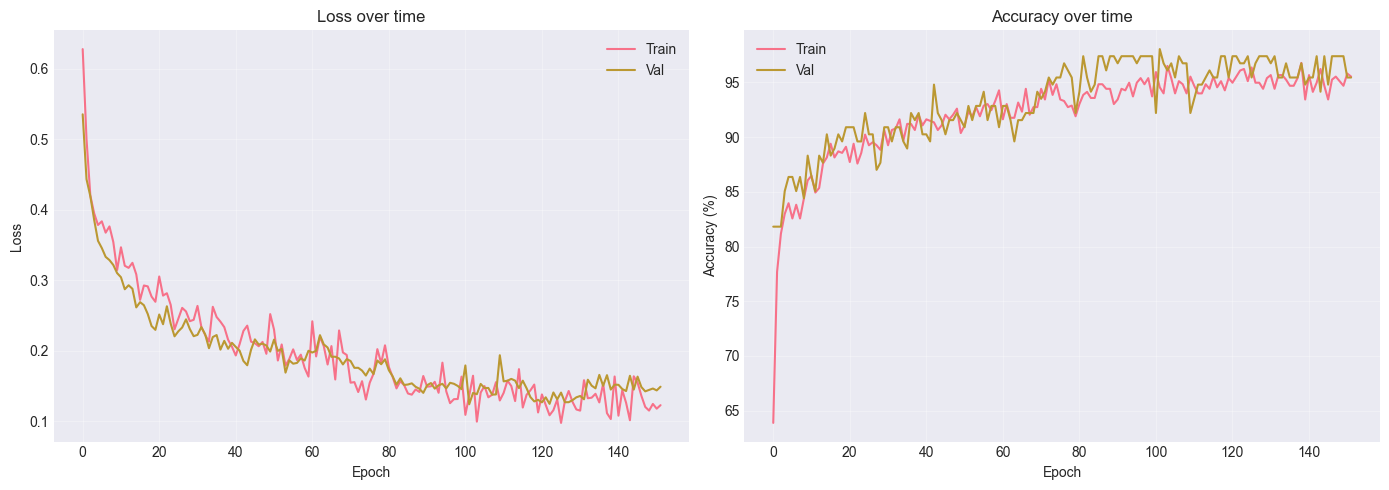

In [45]:
# plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train')
ax1.plot(val_losses, label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over time')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot([x*100 for x in train_accs], label='Train')
ax2.plot([x*100 for x in val_accs], label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy over time')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluate on test set

In [46]:
# get predictions
model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(y_batch.numpy())

y_pred = np.array(y_pred)
y_true = np.array(y_true)

In [47]:
# calculate metrics
mlp_acc = accuracy_score(y_true, y_pred)
mlp_precision = precision_score(y_true, y_pred)
mlp_recall = recall_score(y_true, y_pred)
mlp_f1 = f1_score(y_true, y_pred)

print("MLP Results:")
print(f"Accuracy:  {mlp_acc:.4f} ({mlp_acc*100:.2f}%)")
print(f"Precision: {mlp_precision:.4f}")
print(f"Recall:    {mlp_recall:.4f}")
print(f"F1-Score:  {mlp_f1:.4f}")

MLP Results:
Accuracy:  0.9545 (95.45%)
Precision: 0.9390
Recall:    0.9747
F1-Score:  0.9565


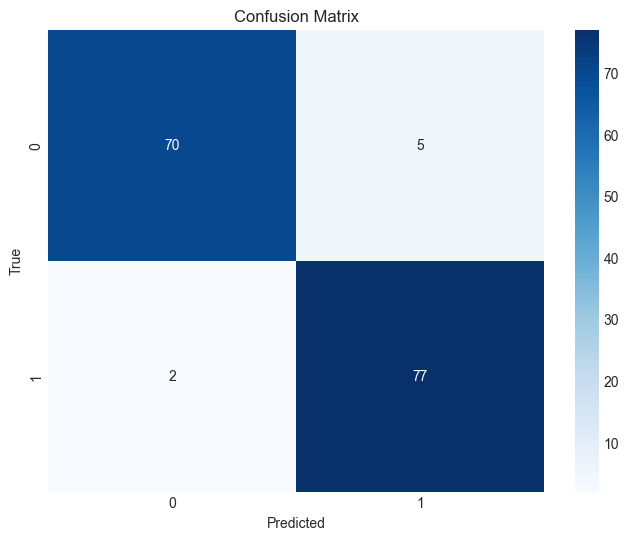

True Negatives: 70
False Positives: 5
False Negatives: 2
True Positives: 77


In [48]:
# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

print(f"True Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Compare with ML methods

In [49]:
# add MLP results
results['MLP'] = {'acc': mlp_acc, 'f1': mlp_f1}

print("\nComparison:")
print(f"{'Method':<12} {'Accuracy':<12} {'F1-Score'}")
print("-" * 40)
for name, metrics in results.items():
    print(f"{name:<12} {metrics['acc']:.4f}       {metrics['f1']:.4f}")


Comparison:
Method       Accuracy     F1-Score
----------------------------------------
KNN          0.8636       0.8679
SVM          0.9481       0.9487
XGBoost      0.9481       0.9500
CatBoost     0.9286       0.9308
MLP          0.9545       0.9565


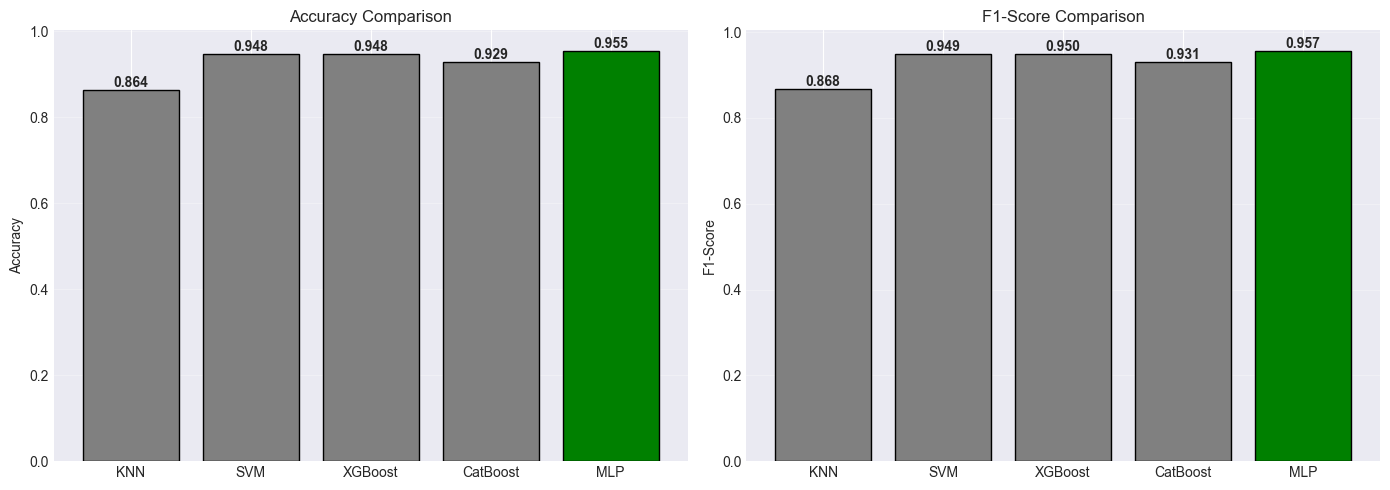

In [50]:
# visualize comparison
methods = list(results.keys())
accuracies = [results[m]['acc'] for m in methods]
f1_scores = [results[m]['f1'] for m in methods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# accuracy comparison
colors = ['gray', 'gray', 'gray', 'gray', 'green']
bars = ax1.bar(methods, accuracies, color=colors, edgecolor='black')
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.3f}',
             ha='center', va='bottom', fontweight='bold')

ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison')
ax1.grid(axis='y', alpha=0.3)

# f1 comparison
bars = ax2.bar(methods, f1_scores, color=colors, edgecolor='black')
for bar, f1 in zip(bars, f1_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{f1:.3f}',
             ha='center', va='bottom', fontweight='bold')

ax2.set_ylabel('F1-Score')
ax2.set_title('F1-Score Comparison')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion

The MLP model performs well compared to traditional methods. Some observations:

**Why MLP works well here:**
- Deep architecture (4 hidden layers) can learn complex feature interactions
- Dropout and batch normalization prevent overfitting
- Small batch size (16) helps with generalization on this dataset
- AdamW optimizer with weight decay provides good regularization


In [51]:
# save model
torch.save({
    'model': model.state_dict(),
    'optimizer': optimizer.state_dict(),
    'test_acc': mlp_acc,
    'test_f1': mlp_f1
}, 'heart_mlp.pth')

print(f"\nModel saved!")
print(f"Test accuracy: {mlp_acc*100:.2f}%")


Model saved!
Test accuracy: 95.45%
